# **Fraud Detection System**

---

## **1. Objective**

The objective of this project is to develop a Fraud Detection System that estimates the likelihood of a transaction being fraudulent in real time.

Rather than relying on a rigid rule-based system, the model is designed to:

* Detect high-risk transactions proactively
* Support real-time fraud monitoring systems
* Minimize financial losses due to fraudulent activities
* Improve overall transaction security and trust

---

## **2. Target Variable Definition**

**Target Variable:** `Class`

| Value | Transaction Outcome    |
| ----: | ---------------------- |
| **1** | Fraudulent Transaction |
| **0** | Legitimate Transaction |

The target variable represents whether a transaction has been confirmed as fraud or not based on historical data.

---

## **3. Machine Learning Task**

* **Problem Type:** Binary Classification
* **Data Characteristics:** Highly imbalanced dataset (fraud cases are extremely rare)
* **Prediction Objective:** Fraud Probability Score
* **Model Output:** Continuous probability score in the range **[0, 1]**

The system is designed for risk scoring and prioritization, enabling identification of suspicious transactions rather than relying solely on binary classification.

---

## **4. Evaluation Philosophy**

The evaluation strategy focuses on detecting fraud effectively while controlling false alarms, which aligns with real-world fraud detection systems.

### **4.1 Primary Metric**

* **ROC–AUC (Receiver Operating Characteristic – Area Under Curve)**
  Measures the model’s ability to distinguish between fraudulent and legitimate transactions across all classification thresholds.

### **4.2 Secondary Metrics**

* **Recall (Fraud Class):**
  Measures the proportion of actual fraudulent transactions correctly identified.
  High recall is critical to minimize undetected fraud.

* **Precision:**
  Measures the proportion of predicted fraud cases that are actually fraud.
  Important to reduce false positives.

* **F1-Score:**
  Balances precision and recall, especially useful in imbalanced datasets.

---

### **4.3 Excluded Metric**

* **Accuracy** is excluded due to extreme class imbalance.

A model can achieve very high accuracy while completely failing to detect fraud, making it unreliable for this use case.

---

## **5. Modeling Principles**

The model is developed based on the following principles:

* Probability-based fraud risk estimation rather than hard classification
* Imbalance-aware modeling techniques (e.g., SMOTE, class weighting)
* Threshold optimization based on business risk tolerance
* Minimization of financial loss due to undetected fraud
* Focus on high recall while maintaining acceptable precision
* Robustness and scalability for real-time deployment scenarios

---

## **6. Business Impact Perspective**

The fraud detection system enables:

* Early identification of suspicious transactions
* Reduction in financial losses due to fraud
* Improved trust in digital payment systems
* Better allocation of investigation resources

---


### **7. Importing Required Libraries**

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve
)

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

### **8. Load ML Ready dataset**

In [6]:
train_df = pd.read_csv(r'C:\Users\tejas\OneDrive\Desktop\CPMLF Capstone Projects\FRAUD DETECTION\data\processed\fraud_train_ml.csv')
test_df = pd.read_csv(r'C:\Users\tejas\OneDrive\Desktop\CPMLF Capstone Projects\FRAUD DETECTION\data\processed\fraud_test_ml.csv')

In [7]:
print(train_df.shape)
print(test_df.shape)


(271922, 34)
(56746, 34)


### **9. Defining Features & Target**

In [8]:
target_col = "Class"

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

In [9]:
X_train.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V24,V25,V26,V27,V28,Hour,Amount_scaled,V1_V2_interaction,V3_V4_interaction,Amount_per_hour
0,2.238954,-1.724499,-2.151484,-2.577803,0.993668,3.565492,-1.785957,0.860122,-1.264003,1.567867,...,0.684735,-0.219028,-0.159167,0.037920,-0.049932,16.0,-0.225531,-3.861074,5.546102,-0.013267
1,-1.315062,1.630783,0.597001,-0.038359,-0.404580,-0.965712,0.212249,0.735381,-1.267926,-0.482635,...,0.515632,-0.713000,-0.266503,-0.017794,0.051058,22.0,-0.325411,-2.144580,-0.022900,-0.014148
2,1.908801,0.021184,-2.087997,0.129310,1.161468,0.605244,-0.022371,0.180296,0.283819,-0.497766,...,-1.689517,0.106098,0.007758,0.045164,-0.053068,11.0,-0.293622,0.040436,-0.269999,-0.024469
3,1.811257,0.316556,0.316751,3.880231,0.048454,1.020163,-0.734868,0.233651,0.681423,1.146705,...,0.702997,-0.212523,-0.010018,-0.017740,-0.038006,1.0,-0.284237,0.573364,1.229069,-0.142119
4,1.358817,-1.120881,0.550266,-1.547659,-1.194950,0.275448,-1.201843,0.212889,-2.094285,1.492821,...,-0.344160,-0.064282,-0.439622,0.062524,0.013095,8.0,-0.257480,-1.523072,-0.851623,-0.028609


### **10. Baseline Model - Logistic Regression**

In [11]:
lr = LogisticRegression( 
    max_iter=3000, 
    class_weight="balanced" 
    )

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,3000
,multi_class,'deprecated'


**Prediction**

In [12]:
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_pred_lr = (y_prob_lr > 0.5).astype(int)

**Evaluation:**

In [13]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

ROC-AUC: 0.9609717485360504
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.86      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



### **11. Tree Model - Random Forest**

In [15]:
rf = RandomForestClassifier( 
    n_estimators=300, 
    max_depth=10, 
    class_weight="balanced", 
    random_state=42, 
    n_jobs=-1 
    )

rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


**Prediction:**

In [16]:
y_prob_rf = rf.predict_proba(X_test)[:,1]
y_pred_rf = (y_prob_rf > 0.5).astype(int)

**Evaluation:**

In [17]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

ROC-AUC: 0.9779387923658152
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.58      0.81      0.68        95

    accuracy                           1.00     56746
   macro avg       0.79      0.90      0.84     56746
weighted avg       1.00      1.00      1.00     56746



### **12. Boosting Model - XGBoost**

In [18]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [20]:
xgb = XGBClassifier( 
    n_estimators=400, 
    max_depth=5, 
    learning_rate=0.05, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    scale_pos_weight=scale_pos_weight, 
    eval_metric="auc", 
    random_state=42 
    )

xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


**Prediction:**

In [21]:
y_prob_xgb = xgb.predict_proba(X_test)[:,1]
y_pred_xgb = (y_prob_xgb > 0.5).astype(int)

**Evaluation:**

In [22]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))

ROC-AUC: 0.973396669729433
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.55      0.81      0.66        95

    accuracy                           1.00     56746
   macro avg       0.78      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746



### **13. Model Comparison**

In [23]:
results = pd.DataFrame({ 
    "Model": ["Logistic", "RandomForest", "XGBoost"], 
    "ROC_AUC": [ 
        roc_auc_score(y_test, y_prob_lr), 
        roc_auc_score(y_test, y_prob_rf), 
        roc_auc_score(y_test, y_prob_xgb) 
        ] 
    })

In [25]:
results.sort_values("ROC_AUC", ascending=False)

,Model,ROC_AUC
1,RandomForest,0.977939
2,XGBoost,0.973397
0,Logistic,0.960972


### **14. Precision-Recall Curve**

In [26]:
precision, recall, thresholds = precision_recall_curve( y_test, y_prob_xgb )

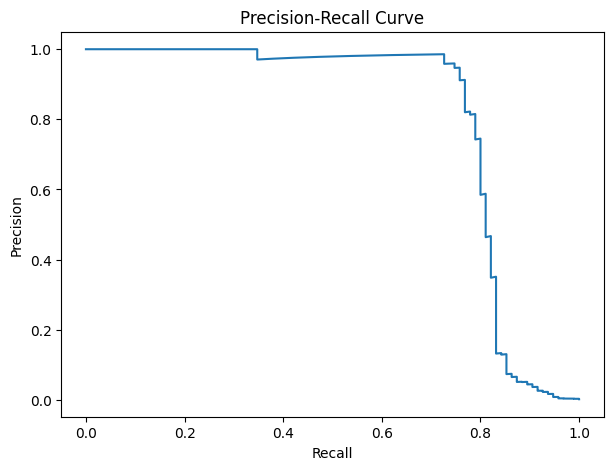

In [27]:
plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


### **15. Threshold Optimization**

In [28]:
threshold = 0.3
y_pred_final = (y_prob_xgb >= threshold).astype(int)

In [29]:
print(confusion_matrix(y_test, y_pred_final))
print(classification_report(y_test, y_pred_final))

[[56523   128]
 [   17    78]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.38      0.82      0.52        95

    accuracy                           1.00     56746
   macro avg       0.69      0.91      0.76     56746
weighted avg       1.00      1.00      1.00     56746



### **16. Fraud Detection Output**

In [30]:
fraud_results = X_test.copy()

fraud_results["fraud_probability"] = y_prob_xgb
fraud_results["fraud_prediction"] = y_pred_final

In [32]:
fraud_results.to_csv(r"C:\Users\tejas\OneDrive\Desktop\CPMLF Capstone Projects\FRAUD DETECTION\data\processed\fraud_ml_results.csv", index=False)

### **17. Final Model Decision**

XGBoost selected because:

- Highest ROC-AUC

- Best fraud detection recall

- Handles imbalance effectively

- Strong non-linear pattern detection

### **18. Final Project Conclusion**

*The developed fraud detection model analyzes transaction patterns to identify suspicious transactions. Using XGBoost with optimized thresholds, the system can detect fraudulent transactions while maintaining manageable false positive rates.*